In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


def first_existing_path(candidates: list[str | Path]) -> Path:
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these files exist: {candidates}")


def parse_bool(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin({"1", "true", "yes", "y"})


def correlation_heatmap(
    dataframe: pd.DataFrame,
    columns: list[str],
    title: str,
    figsize: tuple[int, int] = (10, 8),
) -> pd.DataFrame:
    available_columns = [column for column in columns if column in dataframe.columns]
    if len(available_columns) < 2:
        raise ValueError(f"Need at least two columns for correlation: {available_columns}")

    corr = dataframe[available_columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    for row_idx in range(len(corr.index)):
        for col_idx in range(len(corr.columns)):
            value = corr.iat[row_idx, col_idx]
            text_color = "white" if abs(value) > 0.5 else "black"
            ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", color=text_color)
    fig.colorbar(image, ax=ax, shrink=0.85, label="Correlation")
    fig.tight_layout()
    plt.show()
    return corr


In [14]:
csv_path = first_existing_path(
    [
        "sweep_results.csv",
        "sweep_results_v2_2000.csv",
        "xy_sweep_results.csv",
        "xy_sweep_results-N500-random.csv",
    ]
)

df = pd.read_csv(csv_path)

if "Gait_Quality_Pass" in df.columns:
    successful_df = df.loc[parse_bool(df["Gait_Quality_Pass"])].copy()
    success_rule = "Gait_Quality_Pass == True"
elif "Fell" in df.columns:
    successful_df = df.loc[~parse_bool(df["Fell"])].copy()
    success_rule = "Fell == False"
else:
    raise ValueError("Could not find a success column. Expected Gait_Quality_Pass or Fell.")

print(f"Loaded: {csv_path}")
print(f"Success rule: {success_rule}")
print(f"Successful trials: {len(successful_df)} / {len(df)} ({len(successful_df) / len(df):.2%})")

successful_df.head()


Loaded: sweep_results.csv
Success rule: Gait_Quality_Pass == True
Successful trials: 838 / 121000 (0.69%)


,Mesh_X,Mesh_Y,Mesh_X_Index,Mesh_Y_Index,Pair_Index,Run_Index,Mesh_Generator,Mesh_Generator_Entry_XML,Mesh_Generator_SCAD,Foot_X,Foot_Y,Kp,Kd,Start_Amp_Mult,Start_Freq_Mult,Amplitude_Deg,Frequency_Hz,Replay_Params_JSON,Fell,Distance_Traversed,Forward_Progress,Lateral_Drift,Instantaneous_Forward_Progress,Instantaneous_Forward_Absolute,Instantaneous_Lateral_Progress,Path_Length,Forward_Efficiency,Heading_Change_Deg,Right_Landings,Left_Landings,Landing_Count,Alternating_Steps,Right_Max_Swing_Clearance,Left_Max_Swing_Clearance,Min_Swing_Clearance,Right_Contact_Slip,Left_Contact_Slip,Total_Contact_Slip,Slip_Ratio,Gait_Quality_Pass,Walk_Score,CoT
4356,0.7020,0.87984,0,2,3,1,gen_new_xml,/home/rml3/Documents/nick/LEGO-MuJoCo/bigfoot/...,/home/rml3/Documents/nick/LEGO-MuJoCo/feet_gen...,0.006621,-0.006746,29.571296,7.429038,1.086785,1.153523,28.336046,0.760642,"{""Kd"": 7.429038118960615, ""Kp"": 29.57129625898...",False,0.841701,-0.771793,0.335852,-0.690663,4.171642,1.257309,4.497927,-0.171589,123.472848,1,1,2,1,0.206776,0.281071,0.206776,1.919119,1.817972,3.737091,999.000000,True,-2.478471,0.512189
8122,0.7176,0.84240,1,0,12,1,gen_new_xml,/home/rml3/Documents/nick/LEGO-MuJoCo/bigfoot/...,/home/rml3/Documents/nick/LEGO-MuJoCo/feet_gen...,-0.016870,-0.005149,32.507624,6.553069,1.653627,1.124071,30.345016,0.434578,"{""Kd"": 6.553069351491426, ""Kp"": 32.50762353174...",False,1.100128,0.504057,0.977859,-0.511884,7.208514,6.114962,9.926027,0.050781,98.908711,5,8,13,9,0.071054,0.074983,0.071054,0.739813,0.680317,1.420130,2.817401,True,-0.698183,0.435771
8957,0.7176,0.84240,1,0,12,1,gen_new_xml,/home/rml3/Documents/nick/LEGO-MuJoCo/bigfoot/...,/home/rml3/Documents/nick/LEGO-MuJoCo/feet_gen...,0.005525,-0.007886,41.885030,5.691034,0.815721,1.173736,22.617476,0.443508,"{""Kd"": 5.691033682032311, ""Kp"": 41.88503023613...",False,1.105791,0.411073,1.026544,0.123687,5.919236,2.315017,6.729301,0.061087,27.866331,1,1,2,1,0.033467,0.031906,0.031906,1.990932,2.102947,4.093879,9.959016,True,-1.219691,0.364734
9032,0.7020,1.01088,0,9,10,1,gen_new_xml,/home/rml3/Documents/nick/LEGO-MuJoCo/bigfoot/...,/home/rml3/Documents/nick/LEGO-MuJoCo/feet_gen...,-0.040296,-0.017877,26.460644,8.414161,1.620597,1.261759,27.496942,0.742420,"{""Kd"": 8.414160891474474, ""Kp"": 26.46064378035...",False,0.939411,0.292954,0.892564,1.908134,8.936613,8.856749,13.202427,0.022189,3.840513,4,12,16,7,0.093677,0.175091,0.093677,0.906268,1.143578,2.049845,6.997165,True,-0.869802,1.709039
9201,0.7020,1.01088,0,9,10,1,gen_new_xml,/home/rml3/Documents/nick/LEGO-MuJoCo/bigfoot/...,/home/rml3/Documents/nick/LEGO-MuJoCo/feet_gen...,0.007611,-0.004932,42.011080,2.890303,1.566807,0.759377,23.160543,0.497971,"{""Kd"": 2.8903025506402478, ""Kp"": 42.0110799900...",False,0.182467,-0.181636,0.017400,-0.954001,8.504340,6.052520,11.045020,-0.016445,139.914324,6,4,10,6,0.080061,0.042634,0.042634,0.674608,0.707539,1.382147,999.000000,True,-1.800827,2.817767


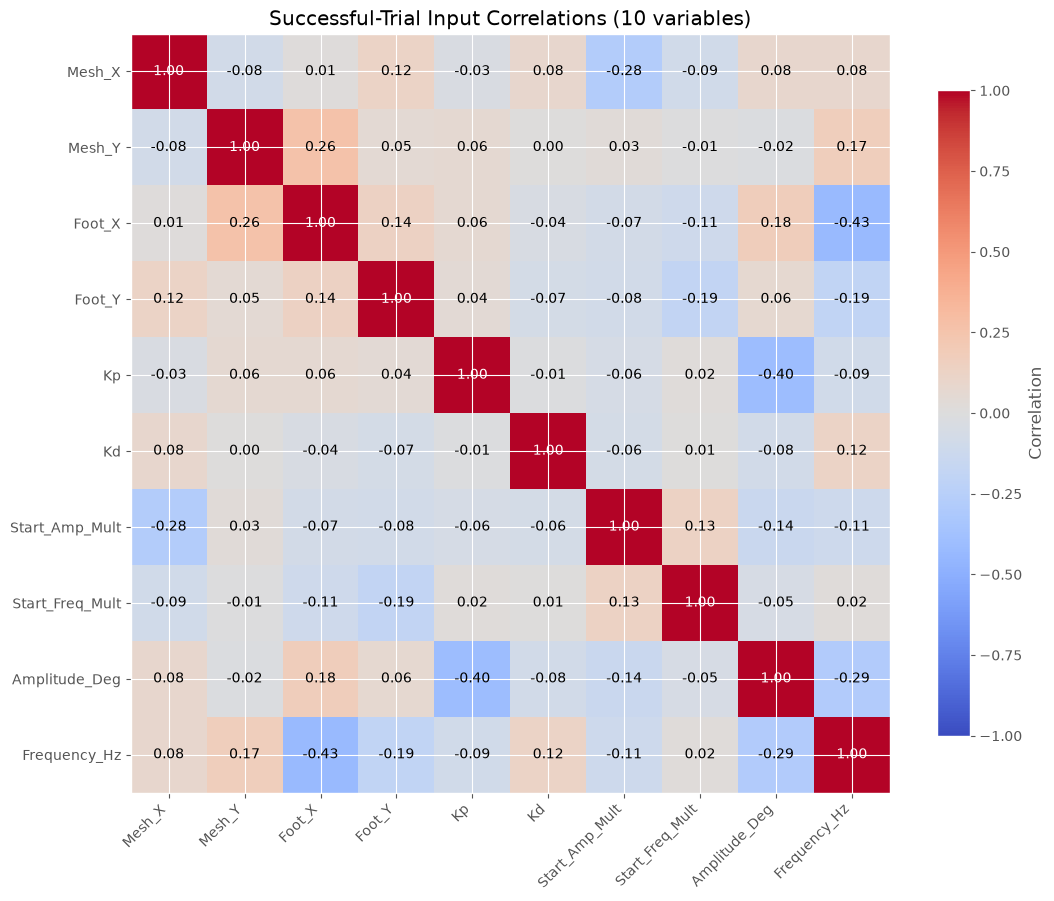

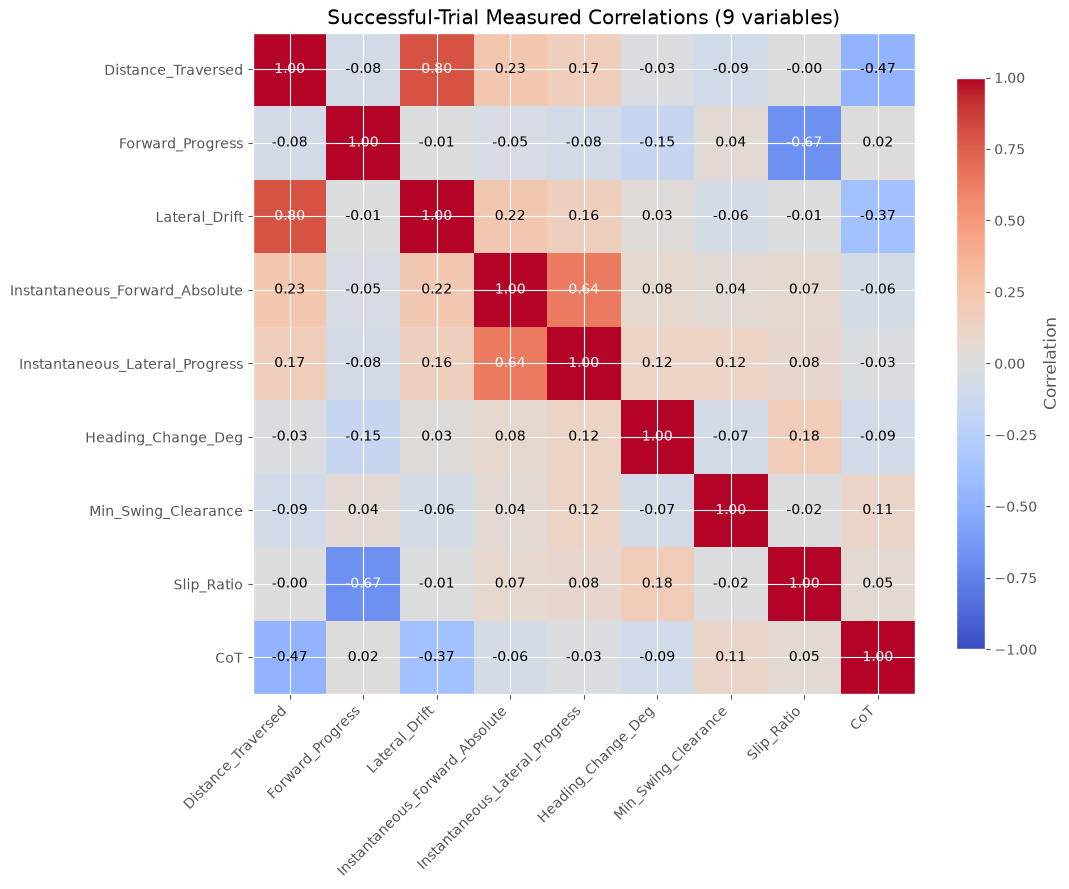

,Mesh_X,Mesh_Y,Foot_X,Foot_Y,Kp,Kd,Start_Amp_Mult,Start_Freq_Mult,Amplitude_Deg,Frequency_Hz
Mesh_X,1.000000,-0.083134,0.010084,0.121043,-0.033028,0.083087,-0.278146,-0.087942,0.080935,0.079866
Mesh_Y,-0.083134,1.000000,0.261978,0.048004,0.057520,0.003958,0.027207,-0.005326,-0.017062,0.166949
Foot_X,0.010084,0.261978,1.000000,0.140274,0.061561,-0.043725,-0.071674,-0.106043,0.175704,-0.429625
Foot_Y,0.121043,0.048004,0.140274,1.000000,0.041141,-0.067715,-0.079038,-0.186376,0.064563,-0.190968
Kp,-0.033028,0.057520,0.061561,0.041141,1.000000,-0.013701,-0.060058,0.016189,-0.399317,-0.087998
Kd,0.083087,0.003958,-0.043725,-0.067715,-0.013701,1.000000,-0.062786,0.007710,-0.078365,0.121126
Start_Amp_Mult,-0.278146,0.027207,-0.071674,-0.079038,-0.060058,-0.062786,1.000000,0.129901,-0.140055,-0.109884
Start_Freq_Mult,-0.087942,-0.005326,-0.106043,-0.186376,0.016189,0.007710,0.129901,1.000000,-0.048611,0.021730
Amplitude_Deg,0.080935,-0.017062,0.175704,0.064563,-0.399317,-0.078365,-0.140055,-0.048611,1.000000,-0.285712
Frequency_Hz,0.079866,0.166949,-0.429625,-0.190968,-0.087998,0.121126,-0.109884,0.021730,-0.285712,1.000000


,Distance_Traversed,Forward_Progress,Lateral_Drift,Instantaneous_Forward_Absolute,Instantaneous_Lateral_Progress,Heading_Change_Deg,Min_Swing_Clearance,Slip_Ratio,CoT
Distance_Traversed,1.000000,-0.075629,0.803956,0.227136,0.165915,-0.029877,-0.092203,-0.004752,-0.467719
Forward_Progress,-0.075629,1.000000,-0.009336,-0.048676,-0.075134,-0.153490,0.039605,-0.674952,0.015409
Lateral_Drift,0.803956,-0.009336,1.000000,0.223650,0.163503,0.027637,-0.064358,-0.012532,-0.374382
Instantaneous_Forward_Absolute,0.227136,-0.048676,0.223650,1.000000,0.640591,0.076262,0.039546,0.072984,-0.064822
Instantaneous_Lateral_Progress,0.165915,-0.075134,0.163503,0.640591,1.000000,0.118420,0.121315,0.081779,-0.028913
Heading_Change_Deg,-0.029877,-0.153490,0.027637,0.076262,0.118420,1.000000,-0.070773,0.180510,-0.092581
Min_Swing_Clearance,-0.092203,0.039605,-0.064358,0.039546,0.121315,-0.070773,1.000000,-0.022528,0.110121
Slip_Ratio,-0.004752,-0.674952,-0.012532,0.072984,0.081779,0.180510,-0.022528,1.000000,0.048049
CoT,-0.467719,0.015409,-0.374382,-0.064822,-0.028913,-0.092581,0.110121,0.048049,1.000000


In [15]:
# Adjust these lists if you want a different subset in the heatmaps.
input_columns = [
    "Mesh_X",
    "Mesh_Y",
    "Foot_X",
    "Foot_Y",
    "Kp",
    "Kd",
    "Start_Amp_Mult",
    "Start_Freq_Mult",
    "Amplitude_Deg",
    "Frequency_Hz",
]

measured_columns = [
    "Distance_Traversed",
    "Forward_Progress",
    "Lateral_Drift",
    "Instantaneous_Forward_Absolute",
    "Instantaneous_Lateral_Progress",
    "Heading_Change_Deg",
    "Min_Swing_Clearance",
    "Slip_Ratio",
    "CoT",
]

input_corr = correlation_heatmap(
    successful_df,
    input_columns,
    title=f"Successful-Trial Input Correlations ({len(input_columns)} variables)",
    figsize=(11, 9),
)

measured_corr = correlation_heatmap(
    successful_df,
    measured_columns,
    title=f"Successful-Trial Measured Correlations ({len(measured_columns)} variables)",
    figsize=(11, 9),
)

display(input_corr)
display(measured_corr)


Rows used in redundancy analysis: 838
Mean output R^2 from inputs: 0.144


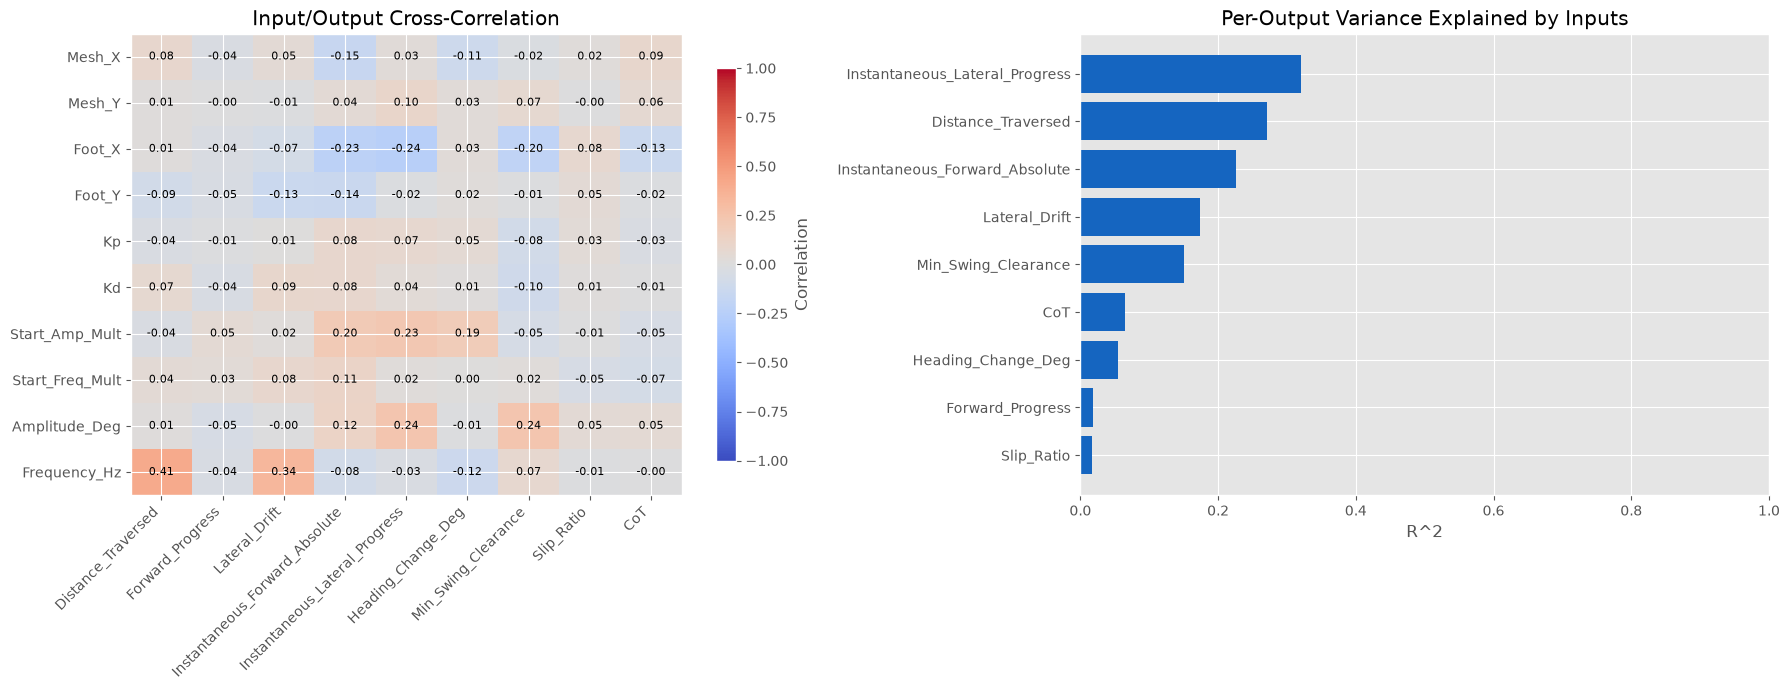

,R2 from inputs
Instantaneous_Lateral_Progress,0.320972
Distance_Traversed,0.270362
Instantaneous_Forward_Absolute,0.225300
Lateral_Drift,0.174223
Min_Swing_Clearance,0.150606
CoT,0.064245
Heading_Change_Deg,0.054630
Forward_Progress,0.017602
Slip_Ratio,0.016881


,Mean abs standardized coefficient
Foot_X,0.219567
Frequency_Hz,0.209613
Amplitude_Deg,0.176994
Mesh_Y,0.124690
Start_Amp_Mult,0.108361
Kp,0.104855
Kd,0.053049
Mesh_X,0.050781
Start_Freq_Mult,0.041155
Foot_Y,0.039004


,Explained fitted variance
RDA Axis 1,0.495806
RDA Axis 2,0.339896
RDA Axis 3,0.093664
RDA Axis 4,0.035133
RDA Axis 5,0.023455


In [16]:
available_input_columns = [column for column in input_columns if column in successful_df.columns]
available_output_columns = [column for column in measured_columns if column in successful_df.columns]

analysis_df = successful_df[available_input_columns + available_output_columns].dropna().copy()
if len(analysis_df) < 3:
    raise ValueError("Not enough successful rows with complete data for redundancy analysis.")

X = analysis_df[available_input_columns].to_numpy(dtype=float)
Y = analysis_df[available_output_columns].to_numpy(dtype=float)

X_std = X.std(axis=0, ddof=0)
Y_std = Y.std(axis=0, ddof=0)
X_std[X_std == 0.0] = 1.0
Y_std[Y_std == 0.0] = 1.0

Xz = (X - X.mean(axis=0)) / X_std
Yz = (Y - Y.mean(axis=0)) / Y_std

# Lightweight redundancy analysis: regress standardized outputs on standardized inputs.
coefficients, _, _, _ = np.linalg.lstsq(Xz, Yz, rcond=None)
Yhat = Xz @ coefficients

per_output_r2 = {}
for output_idx, output_name in enumerate(available_output_columns):
    ss_total = float(np.sum(Yz[:, output_idx] ** 2))
    ss_residual = float(np.sum((Yz[:, output_idx] - Yhat[:, output_idx]) ** 2))
    per_output_r2[output_name] = 1.0 - ss_residual / ss_total if ss_total > 1e-12 else np.nan

per_output_r2 = pd.Series(per_output_r2, name="R2 from inputs").sort_values(ascending=False)
overall_redundancy = float(per_output_r2.mean())

cross_corr = analysis_df[available_input_columns + available_output_columns].corr(numeric_only=True).loc[
    available_input_columns,
    available_output_columns,
]

coefficient_df = pd.DataFrame(
    coefficients,
    index=available_input_columns,
    columns=available_output_columns,
)
mean_abs_coefficients = coefficient_df.abs().mean(axis=1).sort_values(ascending=False)

_, singular_values, _ = np.linalg.svd(Yhat, full_matrices=False)
axis_power = singular_values ** 2
axis_variance_fraction = axis_power / axis_power.sum() if axis_power.sum() > 0 else axis_power
axis_summary = pd.Series(
    axis_variance_fraction[: min(5, len(axis_variance_fraction))],
    index=[f"RDA Axis {idx + 1}" for idx in range(min(5, len(axis_variance_fraction)))],
    name="Explained fitted variance",
)

print(f"Rows used in redundancy analysis: {len(analysis_df)}")
print(f"Mean output R^2 from inputs: {overall_redundancy:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr_image = axes[0].imshow(cross_corr.to_numpy(), cmap="coolwarm", vmin=-1.0, vmax=1.0, aspect="auto")
axes[0].set_title("Input/Output Cross-Correlation")
axes[0].set_xticks(range(len(cross_corr.columns)))
axes[0].set_xticklabels(cross_corr.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(cross_corr.index)))
axes[0].set_yticklabels(cross_corr.index)
for row_idx in range(len(cross_corr.index)):
    for col_idx in range(len(cross_corr.columns)):
        value = cross_corr.iat[row_idx, col_idx]
        text_color = "white" if abs(value) > 0.5 else "black"
        axes[0].text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)
fig.colorbar(corr_image, ax=axes[0], shrink=0.85, label="Correlation")

axes[1].barh(per_output_r2.index[::-1], per_output_r2.values[::-1], color="#1565c0")
axes[1].set_title("Per-Output Variance Explained by Inputs")
axes[1].set_xlabel("R^2")
axes[1].set_xlim(0.0, 1.0)

fig.tight_layout()
plt.show()

display(per_output_r2.to_frame())
display(mean_abs_coefficients.rename("Mean abs standardized coefficient").to_frame())
display(axis_summary.to_frame())
